In [6]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download('nelgiriyewithana/emotions')
df = pd.read_csv(path + '/text.csv')

print(df.shape)
print('Path to dataset files:', path)

(416809, 3)
Path to dataset files: /home/jens/.cache/kagglehub/datasets/nelgiriyewithana/emotions/versions/1


In [7]:
df.describe()

,Unnamed: 0,label
count,416809.000000,416809.000000
mean,208404.000000,1.554271
std,120322.538513,1.490453
min,0.000000,0.000000
25%,104202.000000,0.000000
50%,208404.000000,1.000000
75%,312606.000000,3.000000
max,416808.000000,5.000000


In [8]:
df.sample(5, random_state=42)

,Unnamed: 0,text,label
36130,36130,id say maybe made them feel foolish but that w...,0
138065,138065,i joined the lds church i admit to feeling som...,0
146440,146440,i must admit i didnt feel like hugging him not...,3
103337,103337,i hate that i can still feel if any nerve is d...,0
315528,315528,im actually feeling a little smug,1


In [9]:
EMOTION_MAP = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

df['emotion_name'] = df['label'].map(EMOTION_MAP)

print('Label counts:')
print(df['emotion_name'].value_counts())
print()
print('Unique emotions:', df['emotion_name'].unique())

Label counts:
emotion_name
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

Unique emotions: <StringArray>
['fear', 'sadness', 'love', 'joy', 'surprise', 'anger']
Length: 6, dtype: str


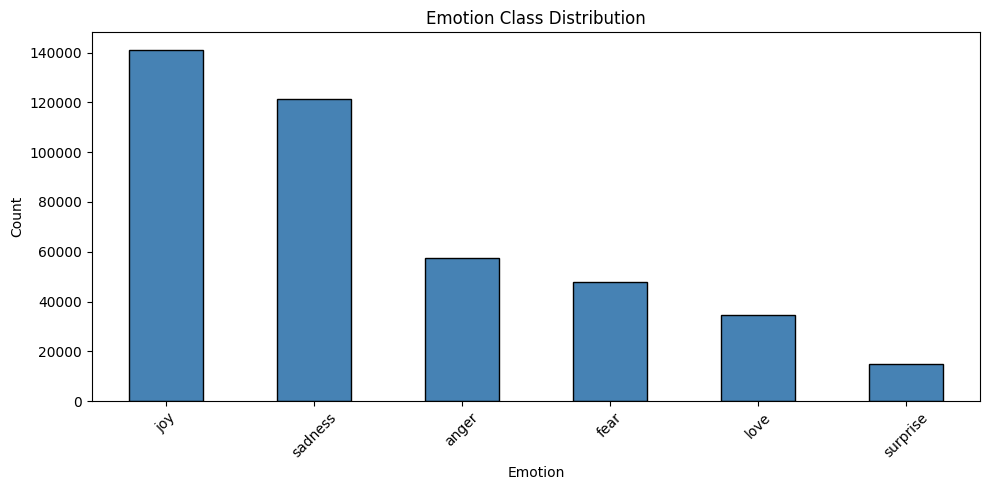

In [10]:
import matplotlib.pyplot as plt

df['emotion_name'].value_counts().plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Clean dataset
print(df.shape)
clean_df = df[['text', 'label', 'emotion_name']].copy()
clean_df.dropna(inplace=True)
clean_df.drop_duplicates(inplace=True)
print(clean_df.shape)
clean_df.head(5)

(416809, 4)
(416123, 3)


,text,label,emotion_name
0,i just feel really helpless and heavy hearted,4,fear
1,ive enjoyed being able to slouch about relax a...,0,sadness
2,i gave up my internship with the dmrg and am f...,4,fear
3,i dont know i feel so lost,0,sadness
4,i am a kindergarten teacher and i am thoroughl...,4,fear


In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    sanitized_text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    sanitized_text = sanitized_text.lower()
    split_text = sanitized_text.split()
    text_without_stopwords = [word for word in split_text if word not in stop_words]
    lemmatized_text = [lemmatizer.lemmatize(word) for word in text_without_stopwords]
    return ' '.join(lemmatized_text)

clean_df['text'] = clean_df['text'].apply(preprocess_text)
clean_df.head(5)

[nltk_data] Downloading package stopwords to /home/jens/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jens/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,label,emotion_name
0,feel really helpless heavy hearted,4,fear
1,ive enjoyed able slouch relax unwind frankly n...,0,sadness
2,gave internship dmrg feeling distraught,4,fear
3,dont know feel lost,0,sadness
4,kindergarten teacher thoroughly weary job take...,4,fear


In [13]:
from sklearn.model_selection import train_test_split

x = clean_df['text'].values
y = clean_df['label'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print('Train size:', len(x_train))
print('Test size: ', len(x_test))

Train size: 332898
Test size:  83225


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from collections import Counter

# Training on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [15]:
VOCAB_SIZE    = 50000
MAX_LEN       = 64
EMBED_DIM     = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
BATCH_SIZE    = 128
EPOCHS        = 5
LEARNING_RATE = 1e-3
NUM_CLASSES   = 6

print('Number of classes:', NUM_CLASSES)

Number of classes: 6


In [16]:
# Build vocabulary from training data
# Special tokens: <PAD> = 0, <UNK> = 1
PAD_IDX = 0
UNK_IDX = 1

all_words  = [word for text in x_train for word in text.split()]
word_counts = Counter(all_words)
vocab       = ['<PAD>', '<UNK>'] + [word for word, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx    = {word: idx for idx, word in enumerate(vocab)}

print('Vocabulary size:', len(vocab))

Vocabulary size: 50000


In [17]:
def encode_text(text, word2idx, max_len):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(word, UNK_IDX) for word in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids


class EmotionDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts    = texts
        self.labels   = labels
        self.word2idx = word2idx
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], self.word2idx, self.max_len)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'label':     torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = EmotionDataset(x_train, y_train, word2idx, MAX_LEN)
test_dataset  = EmotionDataset(x_test,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('Train batches:', len(train_loader))
print('Test batches: ', len(test_loader))

Train batches: 2601
Test batches:  651


In [18]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super(RNNClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Bidirectional LSTM - reads the sequence forwards and backwards
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.dropout    = nn.Dropout(0.3)
        # *2 because bidirectional
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        embedded = self.dropout(self.embedding(input_ids))     # (batch, seq_len, embed_dim)
        output, (hidden, _) = self.rnn(embedded)               # hidden: (num_layers*2, batch, hidden_dim)

        # Concatenate the final forward and backward hidden states
        hidden_fwd = hidden[-2]   # last forward layer
        hidden_bwd = hidden[-1]   # last backward layer
        combined   = torch.cat([hidden_fwd, hidden_bwd], dim=1)  # (batch, hidden_dim*2)

        return self.classifier(self.dropout(combined))          # (batch, num_classes)


model = RNNClassifier(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
    pad_idx     = PAD_IDX
)
model = model.to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

RNNClassifier(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=6, bias=True)
)

Trainable parameters: 8,770,566


In [19]:
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print('Optimizer and loss function ready.')

Optimizer and loss function ready.


In [20]:
import time

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids)
        loss    = criterion(outputs, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if (step + 1) % 100 == 0:
            elapsed = time.time() - start
            print(f'  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} | '
                  f'Loss: {total_loss / (step+1):.4f} | Elapsed: {elapsed:.1f}s')

    avg_loss = total_loss / len(train_loader)
    print(f'\nEpoch {epoch+1} complete - Avg Loss: {avg_loss:.4f}\n')

# Took 6 minutes and 34 seconds on NVIDIA 1080-ti for 5 epochs.

  Epoch 1 | Step 100/2601 | Loss: 1.5086 | Elapsed: 5.2s
  Epoch 1 | Step 200/2601 | Loss: 1.3133 | Elapsed: 10.1s
  Epoch 1 | Step 300/2601 | Loss: 1.0970 | Elapsed: 15.1s
  Epoch 1 | Step 400/2601 | Loss: 0.9411 | Elapsed: 20.0s
  Epoch 1 | Step 500/2601 | Loss: 0.8317 | Elapsed: 25.0s
  Epoch 1 | Step 600/2601 | Loss: 0.7477 | Elapsed: 30.0s
  Epoch 1 | Step 700/2601 | Loss: 0.6802 | Elapsed: 35.0s
  Epoch 1 | Step 800/2601 | Loss: 0.6282 | Elapsed: 40.0s
  Epoch 1 | Step 900/2601 | Loss: 0.5837 | Elapsed: 45.0s
  Epoch 1 | Step 1000/2601 | Loss: 0.5468 | Elapsed: 50.1s
  Epoch 1 | Step 1100/2601 | Loss: 0.5144 | Elapsed: 55.1s
  Epoch 1 | Step 1200/2601 | Loss: 0.4866 | Elapsed: 60.1s
  Epoch 1 | Step 1300/2601 | Loss: 0.4621 | Elapsed: 65.2s
  Epoch 1 | Step 1400/2601 | Loss: 0.4412 | Elapsed: 70.3s
  Epoch 1 | Step 1500/2601 | Loss: 0.4218 | Elapsed: 75.3s
  Epoch 1 | Step 1600/2601 | Loss: 0.4049 | Elapsed: 80.4s
  Epoch 1 | Step 1700/2601 | Loss: 0.3893 | Elapsed: 85.5s
  Epoch

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        labels    = batch['label'].to(device)

        outputs = model(input_ids)
        preds   = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred      = all_preds
y_test_eval = all_labels

accuracy  = accuracy_score(y_test_eval, y_pred)
precision = precision_score(y_test_eval, y_pred, average='weighted')
recall    = recall_score(y_test_eval, y_pred, average='weighted')
f1        = f1_score(y_test_eval, y_pred, average='weighted')

print(f'Accuracy:  {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall:    {recall * 100:.2f}%')
print(f'F1-score:  {f1 * 100:.2f}%')

emotion_names = [EMOTION_MAP[i] for i in range(NUM_CLASSES)]
print('\nClassification Report:\n',
      classification_report(y_test_eval, y_pred, target_names=emotion_names))

Accuracy:  94.02%
Precision: 94.91%
Recall:    94.02%
F1-score:  94.13%

Classification Report:
               precision    recall  f1-score   support

     sadness       0.98      0.97      0.98     24121
         joy       0.99      0.92      0.95     28220
        love       0.78      0.98      0.87      6824
       anger       0.90      0.99      0.95     11448
        fear       0.99      0.82      0.90      9574
    surprise       0.74      1.00      0.85      3038

    accuracy                           0.94     83225
   macro avg       0.90      0.95      0.91     83225
weighted avg       0.95      0.94      0.94     83225



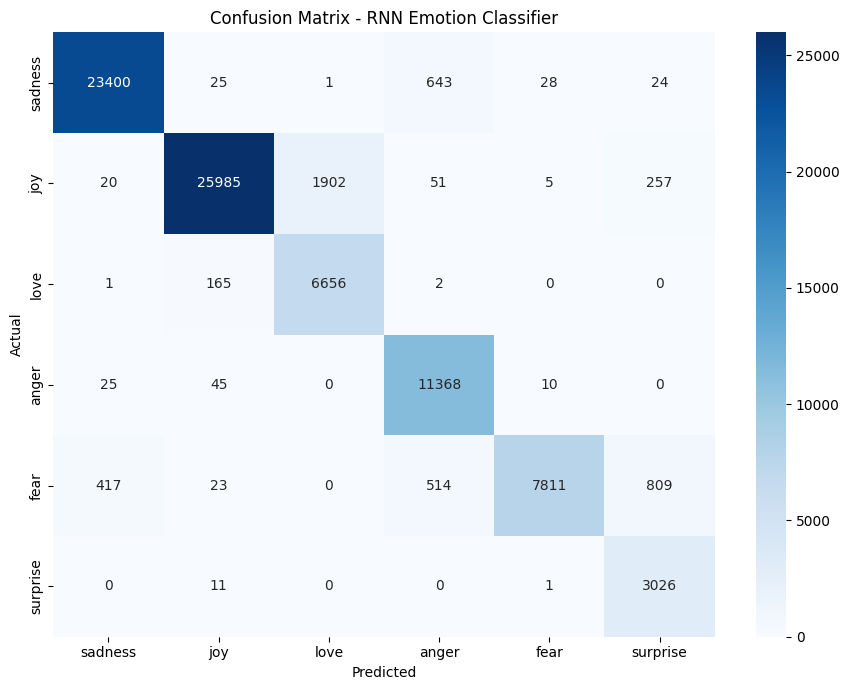

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_eval, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title('Confusion Matrix - RNN Emotion Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
import joblib

torch.save(model.state_dict(), f'emotion_rnn_model_acc_{accuracy * 100:.2f}%.pt')
print('RNN model saved.')

joblib.dump(word2idx, 'emotion_rnn_word2idx.pkl')
print('Vocabulary saved.')

RNN model saved.
Vocabulary saved.


In [24]:
def predict_emotion(text, model, word2idx, max_len=64):
    cleaned = preprocess_text(text)
    model.eval()
    ids       = encode_text(cleaned, word2idx, max_len)
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(input_ids)
        pred   = torch.argmax(output, dim=1).item()

    return EMOTION_MAP[pred]


samples = [
    'I am so happy today, everything is going great!',
    'I feel absolutely devastated and cannot stop crying.',
    'This makes me so angry, I cannot believe it happened.',
    'I am really scared about what might happen next.',
    'Wow, I never expected that to happen!',
    'I love spending time with the people I care about.',
]

print('Emotion Predictions:')
print('--------------------------------------')
for s in samples:
    print(f'Text:    {s}')
    print(f'Emotion: {predict_emotion(s, model, word2idx)}')
    print()

Emotion Predictions:
--------------------------------------
Text:    I am so happy today, everything is going great!
Emotion: joy

Text:    I feel absolutely devastated and cannot stop crying.
Emotion: sadness

Text:    This makes me so angry, I cannot believe it happened.
Emotion: anger

Text:    I am really scared about what might happen next.
Emotion: fear

Text:    Wow, I never expected that to happen!
Emotion: anger

Text:    I love spending time with the people I care about.
Emotion: joy

